In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import time
!{sys.executable} -m pip install xgboost

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

RANDOM_STATE = 42

## 1. Load data and set X, y (same convention as Data_processing.ipynb)

In [2]:
df = pd.read_csv("delaney-processed.csv")

Target = 'measured log solubility in mols per litre'
features = ['Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
    'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area']

X = df[features]
y = df[Target]

print("X:", X.shape, "  y:", y.shape)

X: (1128, 6)   y: (1128,)


In [3]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.20, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} molecules")
print(f"Test : {X_test.shape[0]} molecules")

Train: 902 molecules
Test : 226 molecules


## 3. Evaluation helper

Returns RMSE, MAE, R² so every model reports the same three numbers.

In [4]:
def evaluate(name, y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<25s}  RMSE={rmse:.3f}   MAE={mae:.3f}   R2={r2:.3f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []

## 5. Baseline 2 — Delaney's ESOL model

The `ESOL predicted` column is what Delaney's original 4-parameter linear model
scored. Evaluating it on our test set tells us what number we need to beat to
claim we've done better than the 2004 paper.

In [6]:
delaney_pred_test = df.loc[idx_test, 'ESOL predicted log solubility in mols per litre'].values
results.append(evaluate("Delaney's ESOL model", y_test, delaney_pred_test))

Delaney's ESOL model       RMSE=0.956   MAE=0.708   R2=0.807


## 6. Linear Regression

Ordinary least squares on the 6 features. No regularization, no scaling
(scaling doesn't affect OLS predictions — only their coefficients).

In [47]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results.append(evaluate("Linear Regression", y_test, lr_pred))

# Show the fitted coefficients so we can sanity-check the signs
print("\nCoefficients:")
for f, c in zip(features, lr.coef_):
    print(f"  {f:<28s} {c:+.4f}")
print(f"  {'intercept':<28s} {lr.intercept_:+.4f}")

Linear Regression          RMSE=1.199   MAE=0.892   R2=0.696

Coefficients:
  Minimum Degree               -0.2751
  Molecular Weight             -0.0134
  Number of H-Bond Donors      +0.1083
  Number of Rings              -0.4068
  Number of Rotatable Bonds    -0.1513
  Polar Surface Area           +0.0310
  intercept                    -0.2763


## 7. Ridge Regression

Same linear model with L2 regularization. Not expected to help much on only
6 low-correlation features, but worth including for the comparison.

In [48]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
results.append(evaluate("Ridge (alpha=1.0)", y_test, ridge_pred))

Ridge (alpha=1.0)          RMSE=1.199   MAE=0.892   R2=0.696


In [41]:
#IMPLEMENT GRID SEARCH CV

kf = KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

pipeline = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scale", StandardScaler()),
    ("ridge", Ridge())])

# =========================================================
# DEFINE HYPERPARAMETER GRID FOR RIDGE
# =========================================================


param_grid = {

    "poly__degree": [1, 2, 3, 4, 5],
     "ridge__alpha": [0.001, 0.01, 0.1,1.0,10.0,100.0]
}

#=============================DO GRID_SEARCH_CV================================
# GRID SEARCH CV EXHAUSTIVELY TESTS EVERY COMBINATION OF THE
# SPECIFIED HYPERPARAMETER VALUES USING CROSS-VALIDATION AND
# SELECTS THE COMBINATION THAT GIVES THE BEST VALIDATION SCORE.
# IN OTHER WORDS, IT EXPLORES ALL PERMUTATIONS/COMBINATIONS
# DEFINED BY THE USER'S HYPERPARAMETER GRID.

grid = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=kf,scoring="neg_root_mean_squared_error",return_train_score=True)

grid.fit(X_train, y_train)      #PERFORM THE SEARCH USING TRAINING DATA

#=====================PRINT THE BEST HYPERPARAMETERS================================
print("\nGrid Search CV completed.")
print("\nBest hyperparameters: ")
print(grid.best_params_)

print("\nBest mean CV RMSE: ")
print(-grid.best_score_)


#===================================FINAL MODEL===============================

final_model = grid.best_estimator_     #FITS THE MODEL WITH THE BEST HYPERPARAMETERS

y_test_pred = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test_pred,y_test)
final_r2 = r2_score(y_test, y_test_pred)

print("\nFINAL TEST RMSE:", final_rmse)
print("\nFINAL TEST R2:", final_r2)


Grid Search CV completed.

Best hyperparameters: 
{'poly__degree': 3, 'ridge__alpha': 1.0}

Best mean CV RMSE: 
0.9614945315750875

FINAL TEST RMSE: 1.056547773010769

FINAL TEST R2: 0.7638376126409812


In [19]:
#GRID CV for RANDOM FOREST ALGORITHM 
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
kf = KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

param_grid = {"n_estimators":[100,200,500],
             "max_depth":[None,5,10,20],
             "min_samples_leaf":[1,2,4],
             "max_features":[1.0,"sqrt"]}

grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=kf,scoring="neg_root_mean_squared_error",return_train_score=True,
                       n_jobs=1,pre_dispatch=2)

grid_rf.fit(X_train,y_train)

print("Best parameters:", grid_rf.best_params_)
print("Best CV RMSE:", -grid_rf.best_score_)

rf_best = grid_rf.best_estimator_  #GET THE BEST MODEL

y_pred_rf = rf_best.predict(X_test)

print("Test RMSE:",root_mean_squared_error(y_test, y_pred_rf))

print("Test R2:",r2_score(y_test, y_pred_rf))
final_rmse = root_mean_squared_error(y_test, y_pred_rf)

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV RMSE: 0.8527332265210822
Test RMSE: 0.8747565559792112
Test R2: 0.8381149049393255


In [10]:
#CHECK THE FEATURE IMPORTANCES WITH RANDOM FOREST

importance = pd.Series(rf_best.feature_importances_,index=features).sort_values(ascending=False)
print(importance)


Molecular Weight             0.449640
Polar Surface Area           0.195635
Number of Rings              0.175609
Number of Rotatable Bonds    0.111108
Number of H-Bond Donors      0.056076
Minimum Degree               0.011932
dtype: float64


In [21]:
#NOW WE CAN VERIFY THAT WHETEHER IT IS REALLY THE IMPORTANT FEATURE (MW) BY SHUFFLING THAT FEATURE AMONG IN THE TESTING SET. 
#IF THE RMSE CHANGES DRASTICALLY,THEN IT REALLY A IMPORTANT ONE. 

from sklearn.inspection import permutation_importance

perm = permutation_importance(rf_best, X_test,y_test,n_repeats=20,random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",n_jobs=1)

perm_importance = pd.Series(perm.importances_mean,index=features).sort_values(ascending=False)

print(perm_importance)

X_test_shuffled = X_test.copy()

X_test_shuffled["Molecular Weight"] = np.random.permutation( X_test_shuffled["Molecular Weight"].values)
y_pred_shuffled = rf_best.predict(X_test_shuffled)

shuffled_rmse = root_mean_squared_error(y_test,y_pred_shuffled)
shuffled_r2 = r2_score(y_test,y_pred_shuffled)

print("RMSE after shuffling MW:", shuffled_rmse)
print("R2 after shuffling MW:", shuffled_r2)
print("CHANGE in RMSE:",abs(shuffled_rmse - final_rmse))

Molecular Weight             1.135495
Polar Surface Area           0.786310
Number of Rings              0.481073
Number of Rotatable Bonds    0.212892
Number of H-Bond Donors      0.128026
Minimum Degree               0.016982
dtype: float64
RMSE after shuffling MW: 1.9913201577735535
R2 after shuffling MW: 0.161091426885979
CHANGE in RMSE: 1.1165636017943423


In [36]:
#GRADIENT BOOSTING REGRESSOR
start_time = time.time()
gbr =GradientBoostingRegressor(random_state=RANDOM_STATE)

gbr_param_grid = {"n_estimators":[100,200,500],
             "learning_rate":[0.01,0.05,0.1],
             "max_depth":[2,3,4],
             "min_samples_leaf":[1,2,4],
             "subsample": [0.8, 1.0]}

grid_gbr= GridSearchCV(estimator=gbr,param_grid=gbr_param_grid,cv=kf,scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=1)

grid_gbr.fit(X_train, y_train)

best_gbr = grid_gbr.best_estimator_   
y_pred_gbr = best_gbr.predict(X_test)

gb_rmse = root_mean_squared_error(y_test, y_pred_gbr)
gb_r2 = r2_score(y_test, y_pred_gbr)
end_time = time.time()
elapsed_time = end_time - start_time
 

print("\nTest RMSE:", gb_rmse)
print("Test R2:", gb_r2)
print(f"\nTotal runtime: {elapsed_time:.2f} seconds")


Test RMSE: 0.875933318162602
Test R2: 0.8376790616377543

Total runtime: 79.60 seconds


In [53]:
# =========================================================
# XGBOOST REGRESSOR
# =========================================================
start_time = time.time()
xgb = XGBRegressor(objective="reg:squarederror",random_state=RANDOM_STATE,n_jobs=1,
    tree_method="hist")

# =========================================================
# HYPERPARAMETER GRID
# =========================================================

xgb_param_grid = {"n_estimators": [100, 200, 500], "learning_rate": [0.01, 0.05, 0.1],
"max_depth": [2, 3, 4],"subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0]
}

# =========================================================
# GRID SEARCH CV
# =========================================================

grid_xgb = GridSearchCV(estimator=xgb,param_grid=xgb_param_grid,cv=kf,
    scoring="neg_root_mean_squared_error",return_train_score=True,
    n_jobs=1
)

grid_xgb.fit(X_train, y_train)

# =========================================================
# BEST MODEL
# =========================================================

print("\nBest parameters:")
print(grid_xgb.best_params_)

print("\nBest CV RMSE:")
print(-grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_
xgb_importance = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print(xgb_importance)

# =========================================================
# FINAL TEST PERFORMANCE
# =========================================================

y_pred_xgb = best_xgb.predict(X_test)

xgb_rmse = root_mean_squared_error(y_test,y_pred_xgb)

xgb_r2 = r2_score(y_test,y_pred_xgb)

print("\nTest XGB RMSE:", xgb_rmse)
print("Test XGB R2:", xgb_r2)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal runtime: {elapsed_time:.2f} seconds")
 


Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}

Best CV RMSE:
0.8179655384073115
Molecular Weight             0.290155
Polar Surface Area           0.208478
Number of Rings              0.198977
Number of H-Bond Donors      0.135327
Number of Rotatable Bonds    0.129011
Minimum Degree               0.038051
dtype: float32

Test XGB RMSE: 0.87436921214547
Test XGB R2: 0.8382582392417198

Total runtime: 9.11 seconds


Molecular Weight             0.290155
Polar Surface Area           0.208478
Number of Rings              0.198977
Number of H-Bond Donors      0.135327
Number of Rotatable Bonds    0.129011
Minimum Degree               0.038051
dtype: float32


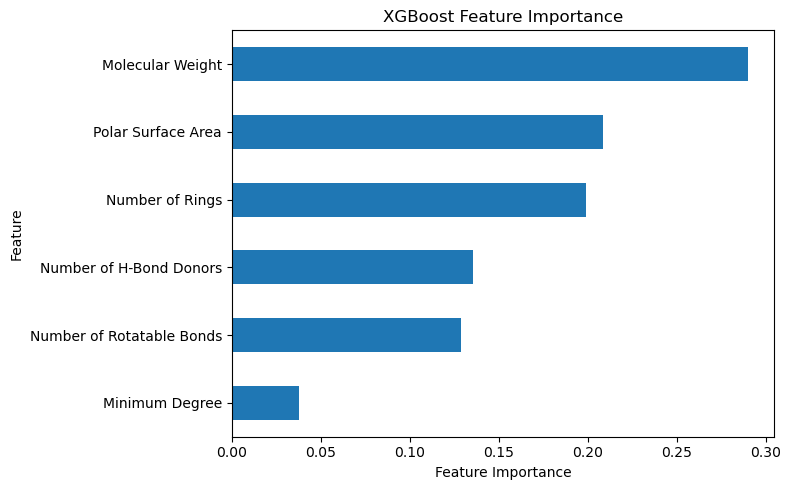

In [56]:

plt.figure(figsize=(8, 5))
xgb_importance.sort_values().plot(kind="barh")
print(xgb_importance)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

In [50]:
# =========================================================
# COLLECT PREDICTIONS FROM ALL BEST MODELS
# =========================================================

best_ridge = grid.best_estimator_
best_rf = grid_rf.best_estimator_
best_gbr = grid_gbr.best_estimator_
best_xgb = grid_xgb.best_estimator_

y_pred_ridge = best_ridge.predict(X_test)
y_pred_rf = best_rf.predict(X_test)
y_pred_gbr = best_gbr.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)


# =========================================================
# FINAL COMPARISON TABLE
# =========================================================

results = pd.DataFrame({
    "Model": [
        
         
        "Polynomial Ridge",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "CV RMSE": [
         
         
        -grid.best_score_,
        -grid_rf.best_score_,
        -grid_gbr.best_score_,
        -grid_xgb.best_score_
    ],

    "Test RMSE": [
         
         
        root_mean_squared_error(y_test, y_pred_ridge),
        root_mean_squared_error(y_test, y_pred_rf),
        root_mean_squared_error(y_test, y_pred_gbr),
        root_mean_squared_error(y_test, y_pred_xgb)
    ]
})

print(results.round(4))

               Model  CV RMSE  Test RMSE
0   Polynomial Ridge   0.9615     1.0565
1      Random Forest   0.8527     0.8748
2  Gradient Boosting   0.8330     0.8759
3            XGBoost   0.8180     0.8744


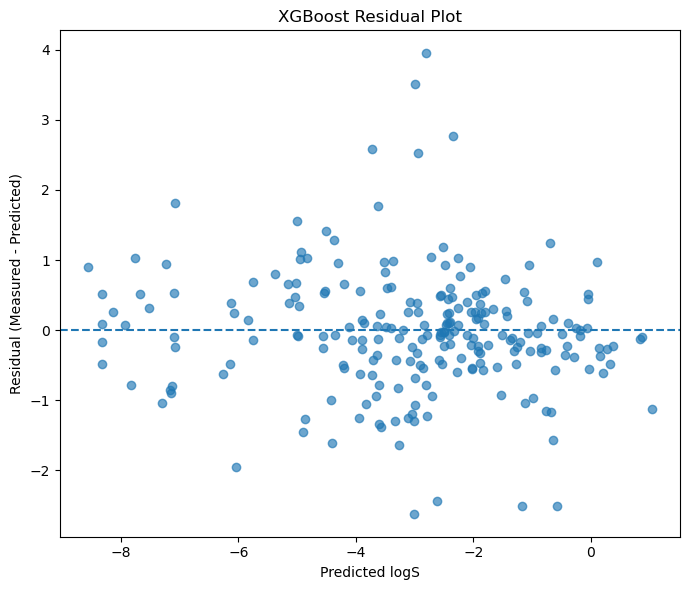

In [52]:
# =========================================================
# RESIDUAL PLOT
# =========================================================

residuals_xgb = y_test - y_pred_xgb

plt.figure(figsize=(7, 6))

plt.scatter(y_pred_xgb,residuals_xgb,alpha=0.65)

plt.axhline(y=0,linestyle="--")

plt.xlabel("Predicted logS")
plt.ylabel("Residual (Measured - Predicted)")
plt.title("XGBoost Residual Plot")

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# PREDICTED vs ACTUAL + RESIDUALS (SIDE-BY-SIDE DIAGNOSTIC)
# =========================================================
# LEFT PANEL : PREDICTED vs ACTUAL WITH y=x DIAGONAL.
#   POINTS ON THE DIAGONAL  = PERFECT PREDICTION.
#   POINTS FLATTENING AT THE EXTREMES = MODEL SATURATION
#     (IT UNDER-PREDICTS THE MOST INSOLUBLE MOLECULES AND
#      OVER-PREDICTS THE MOST SOLUBLE ONES).
# RIGHT PANEL : RESIDUALS vs PREDICTED.
#   HORIZONTAL BAND AROUND 0 = UNBIASED, HOMOSCEDASTIC ERRORS.
#   FAN / CURVE SHAPE        = HETEROSCEDASTICITY OR BIAS.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- LEFT: PREDICTED vs ACTUAL ---
axes[0].scatter(y_test, y_pred_xgb, alpha=0.55, s=25)
lo = min(y_test.min(), y_pred_xgb.min())
hi = max(y_test.max(), y_pred_xgb.max())
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
axes[0].set_xlabel("Measured logS")
axes[0].set_ylabel("Predicted logS")
axes[0].set_title(f"XGBoost: Predicted vs Actual (RMSE={xgb_rmse:.3f})")
axes[0].legend()

# --- RIGHT: RESIDUALS ---
residuals_xgb = y_test - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuals_xgb, alpha=0.55, s=25)
axes[1].axhline(y=0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted logS")
axes[1].set_ylabel("Residual (Measured - Predicted)")
axes[1].set_title("XGBoost: Residuals vs Predicted")

plt.tight_layout()
plt.show()


In [51]:
# =========================================================
# PROVIDED ESOL PREDICTIONS
# =========================================================

esol_pred = df.loc[X_test.index,
    "ESOL predicted log solubility in mols per litre"]

esol_rmse = root_mean_squared_error(y_test,esol_pred)

esol_r2 = r2_score(y_test,esol_pred)

print("Provided ESOL RMSE:", esol_rmse)
print("Provided ESOL R2:", esol_r2)

print("\nOur XGBoost RMSE:", root_mean_squared_error(y_test, y_pred_xgb))

print("Our XGBoost R2:",r2_score(y_test, y_pred_xgb))

Provided ESOL RMSE: 0.9560406552617281
Provided ESOL R2: 0.8066317466875239

Our XGBoost RMSE: 0.87436921214547
Our XGBoost R2: 0.8382582392417198
